# 📉 Customer Churn Prediction
**End-to-end machine learning and deep learning project to predict telecom customer churn using billing, tenure, and service subscription data.**

---
**Dataset:** Telecom Customer Churn | **Target:** Churn (Yes / No) | **Records:** ~7,043 customers  
**Stack:** Python · Pandas · Scikit-Learn · TensorFlow · Keras Tuner · Seaborn · Plotly


In [1]:
# importing basic much needed library:-
import pandas as pd
import numpy as np  
import seaborn as  sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
import plotly.express  as  px
import statistics as sts
import pickle 
import os
from tensorflow.keras import layers, models

# Reading dataset

## 📂 Dataset Overview

The dataset contains **7,043 records** of telecom customers with 21 features covering demographics, account information, and subscribed services.

| Column | Description |
|--------|-------------|
| `customerID` | Unique customer identifier |
| `gender` | Customer gender (Male / Female) |
| `SeniorCitizen` | Whether the customer is a senior citizen (1 = Yes) |
| `Partner` / `Dependents` | Whether customer has partner or dependents |
| `tenure` | Number of months with the company |
| `PhoneService`, `MultipleLines` | Phone service subscription details |
| `InternetService`, `OnlineSecurity`, `OnlineBackup` | Internet add-on services |
| `Contract` | Contract type: Month-to-month / One year / Two year |
| `PaymentMethod` | Electronic check / Mailed check / Bank transfer / Credit card |
| `MonthlyCharges` | Current monthly bill amount |
| `TotalCharges` | Total amount charged to date |
| `Churn` | **Target variable** — whether the customer churned (Yes / No) |


In [2]:
df=pd.read_csv(r'customer_churn.csv')

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
print(df['Churn'].unique())

['No' 'Yes']


In [6]:
df['Churn']=df['Churn'].map({'Yes':1 ,'No': 0})
df['Churn']=pd.to_numeric(df['Churn'], errors='coerce')


In [7]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.shape

(7043, 21)

In [10]:
df['tenure'].unique()          

array([ 1, 34,  2, 45,  8, 22, 10, 28, 62, 13, 16, 58, 49, 25, 69, 52, 71,
       21, 12, 30, 47, 72, 17, 27,  5, 46, 11, 70, 63, 43, 15, 60, 18, 66,
        9,  3, 31, 50, 64, 56,  7, 42, 35, 48, 29, 65, 38, 68, 32, 55, 37,
       36, 41,  6,  4, 33, 67, 23, 57, 61, 14, 20, 53, 40, 59, 24, 44, 19,
       54, 51, 26,  0, 39])

In [11]:
''' as we can see here there  is zero tenure '''

' as we can see here there  is zero tenure '

In [12]:
df[df['tenure']==0].shape[0]

11

In [13]:
df[(df['MonthlyCharges']== 0 )].shape[0]

0

In [14]:
df[(df['TotalCharges']==0 )].shape[0]

0

In [15]:
df[(df['TotalCharges']==' ' )].shape[0]

11

In [16]:
# there were 11 zero in the tenure column and there are  no zero values in the  monthly charges  as we know total  charges are monthly charges multiply 
# by tenure ( tc=t*mc) so 11 total charges value should  be zero but there are no zero value but it is spaced values there . so we will replace it by 
# some method . 

In [17]:
df[df['TotalCharges'].str.match(r'^\D')][['TotalCharges','MonthlyCharges','tenure']] # non digit  checking or we can use 
# df[df['TotalCharges']==' ' ]['TotalCharges']

,TotalCharges,MonthlyCharges,tenure
488,,52.55,0
753,,20.25,0
936,,80.85,0
1082,,25.75,0
1340,,56.05,0
3331,,19.85,0
3826,,25.35,0
4380,,20.00,0
5218,,19.70,0
6670,,73.35,0


In [18]:
# so these specific rows are having spaced value  

In [19]:
df['TotalCharges']=df['MonthlyCharges']*df['tenure']

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [21]:
df['TotalCharges'].replace(' ' , 0 )

0         29.85
1       1936.30
2        107.70
3       1903.50
4        141.40
         ...   
7038    2035.20
7039    7430.40
7040     325.60
7041     297.60
7042    6972.90
Name: TotalCharges, Length: 7043, dtype: float64

In [22]:
df[df['TotalCharges']== ' '].shape[0]

0

In [23]:
# now there  are no spaced values in the TotalCharges feature 

---
## 🔍 Data Cleaning Summary

| Issue Found | Fix Applied |
|-------------|-------------|
| `Churn` column stored as `Yes/No` string | Mapped to binary `1/0` |
| `TotalCharges` had 11 whitespace entries (tenure = 0) | Recalculated as `MonthlyCharges × tenure` |
| No duplicate rows found | No action needed |
| No remaining null values after fix | Dataset ready for analysis |

**Key Observation:** 11 customers with `tenure = 0` had blank `TotalCharges` — logically correct since `TotalCharges = MonthlyCharges × tenure`. These were recalculated programmatically rather than dropped to preserve records.


## 1. 🗂️ Data Manipulation

Filtering and slicing operations to extract meaningful customer subsets based on business conditions.

In [24]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1936.30,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,107.70,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1903.50,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,141.40,1


In [25]:
#● Extract the 5th column and store it in ‘customer_5’
customer_5 = df['Dependents']
customer_5

0        No
1        No
2        No
3        No
4        No
       ... 
7038    Yes
7039    Yes
7040    Yes
7041     No
7042     No
Name: Dependents, Length: 7043, dtype: object

In [26]:
#● Extract the 15th column and store it in ‘customer_15’
customer_15 = df['StreamingMovies']

In [27]:
#● Extract all the male senior citizens whose payment method is electronic
#check and store the result in ‘senior_male_electronic’

In [28]:
df['PaymentMethod'].unique()

array(['Electronic check', 'Mailed check', 'Bank transfer (automatic)',
       'Credit card (automatic)'], dtype=object)

In [29]:
senior_male_electronic = df[(df['gender']=='Male') & (df['SeniorCitizen']== 1) & (df['PaymentMethod' ]=='Electronic check')]
senior_male_electronic.T

,20,55,57,78,91,129,168,214,245,247,...,6717,6773,6809,6819,6836,6837,6894,6914,6967,7032
customerID,8779-QRDMV,1658-BYGOY,5067-XJQFU,0191-ZHSKZ,2424-WVHPL,2639-UGMAZ,3445-HXXGF,2504-DSHIH,0221-WMXNQ,9947-OTFQU,...,3768-NLUBH,3990-QYKBE,9274-CNFMO,3005-NFMTA,5868-YWPDW,6229-LSCKB,1400-MMYXY,7142-HVGBG,8739-WWKDU,6894-LFHLY
gender,Male,Male,Male,Male,Male,Male,Male,Male,Male,Male,...,Male,Male,Male,Male,Male,Male,Male,Male,Male,Male
SeniorCitizen,1,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
Partner,No,No,Yes,No,No,No,Yes,Yes,No,No,...,Yes,Yes,Yes,No,Yes,No,Yes,Yes,No,No
Dependents,No,No,Yes,No,No,No,No,No,No,No,...,No,No,No,No,No,No,No,No,No,No
tenure,1,18,66,30,1,71,58,23,4,15,...,57,37,4,55,6,6,3,43,25,1
PhoneService,No,Yes,Yes,Yes,Yes,No,No,Yes,Yes,Yes,...,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes
MultipleLines,No phone service,Yes,Yes,No,No,No phone service,No phone service,Yes,No,No,...,Yes,Yes,Yes,Yes,No,No,Yes,Yes,Yes,Yes
InternetService,DSL,Fiber optic,Fiber optic,DSL,Fiber optic,DSL,DSL,Fiber optic,Fiber optic,Fiber optic,...,Fiber optic,Fiber optic,Fiber optic,Fiber optic,Fiber optic,Fiber optic,Fiber optic,Fiber optic,Fiber optic,Fiber optic
OnlineSecurity,No,No,No,Yes,No,Yes,No,No,Yes,No,...,No,No,No,Yes,No,No,No,No,No,No


In [30]:
# there are only 298 value having all these three conditions

In [31]:
#● Extract all those customers whose tenure is greater than 70 months or their monthly charges is more than $100 and store the result in
#‘customer_total_tenure’

In [32]:
customer_total_tenure=df[(df['tenure']> 70) & ( df['MonthlyCharges']> 100 )]
customer_total_tenure.T

,17,59,94,106,193,198,202,241,369,437,...,6686,6700,6728,6768,6793,6859,6934,6992,7022,7039
customerID,9959-WOFKT,5954-BDFSG,9848-JQJTX,6728-DKUCO,9680-NIAUV,7255-SSFBC,3363-DTIVD,6614-FHDBO,3520-FJGCV,4376-KFVRS,...,4670-TABXH,8107-RZLNV,2380-DAMQP,9739-JLPQJ,1320-GVNHT,3508-CFVZL,6257-DTAYD,0218-QNVAS,7203-OYKCT,2234-XADUH
gender,Male,Female,Male,Female,Female,Male,Male,Male,Male,Male,...,Male,Male,Female,Female,Male,Female,Male,Male,Male,Female
SeniorCitizen,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
Partner,No,No,No,Yes,Yes,Yes,Yes,No,Yes,Yes,...,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,No,Yes
Dependents,Yes,No,No,Yes,Yes,Yes,Yes,No,Yes,Yes,...,No,No,No,Yes,Yes,No,No,Yes,No,Yes
tenure,71,72,72,72,72,72,71,72,72,72,...,72,72,72,72,72,71,71,71,72,72
PhoneService,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,...,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes
MultipleLines,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,...,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes
InternetService,Fiber optic,Fiber optic,Fiber optic,Fiber optic,Fiber optic,Fiber optic,Fiber optic,Fiber optic,Fiber optic,Fiber optic,...,Fiber optic,Fiber optic,Fiber optic,Fiber optic,Fiber optic,Fiber optic,Fiber optic,Fiber optic,Fiber optic,Fiber optic
OnlineSecurity,Yes,No,No,Yes,Yes,No,Yes,No,Yes,Yes,...,No,No,Yes,Yes,Yes,Yes,No,No,No,No


In [33]:
#------- there are 175 customer whose monthly charges are more  than $100 and the tenure  is more than 70 months

In [34]:
# ●Extract all the customers whose contract is of two years, payment method is mailed check and the value of churn is ‘Yes’ and store the result in
#‘two_mail_yes’

In [35]:
two_mail_yes = df[(df['Contract']== 'Two year') & (df['PaymentMethod']=='Mailed check') & (df['Churn']=='Yes')]

In [36]:
two_mail_yes

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


In [37]:
# only customers are satisfying the above condition


In [38]:
#● **Extract 333 random records from the customer_churndataframe and store the result in ‘customer_333

In [39]:
customer_333 = df.sample(333, random_state=42)

In [40]:
customer_333

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
185,1024-GUALD,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,24.80,24.80,1
2715,0484-JPBRU,Male,0,No,No,41,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Bank transfer (automatic),25.25,1035.25,0
3825,3620-EHIMZ,Female,0,Yes,Yes,52,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.35,1006.20,0
1807,6910-HADCM,Female,0,No,No,1,Yes,No,Fiber optic,No,...,Yes,No,No,No,Month-to-month,No,Electronic check,76.35,76.35,1
132,8587-XYZSF,Male,0,No,No,67,Yes,No,DSL,No,...,No,Yes,No,No,Two year,No,Bank transfer (automatic),50.55,3386.85,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1451,6890-PFRQX,Male,0,No,No,18,Yes,Yes,DSL,Yes,...,Yes,No,Yes,No,Month-to-month,No,Mailed check,69.50,1251.00,0
3601,1552-CZCLL,Female,0,Yes,Yes,55,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Credit card (automatic),20.00,1100.00,0
2149,2014-MKGMH,Female,0,No,No,46,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Electronic check,101.10,4650.60,0
5141,0303-WMMRN,Male,0,No,No,5,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Mailed check,19.25,96.25,0


In [41]:
#● Get the count of different levels from the ‘Churn’ column
df['Churn'].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

## 2. 📊 Data Visualization

Visual exploration of key features — internet service distribution, customer tenure, and the relationship between tenure and monthly charges.

In [42]:
# # ● Build a bar-plot for the ’InternetService’ column:
# a. Set x-axis label to ‘Categories of Internet Service’
# b. Set y-axis label to ‘Count of Categories’
# c. Set df['InternetService']the title of plot to be ‘Distribution of Internet Service’
# d. Set the color of the bars to be ‘orange

In [43]:
df['InternetService'].value_counts()

InternetService
Fiber optic    3096
DSL            2421
No             1526
Name: count, dtype: int64

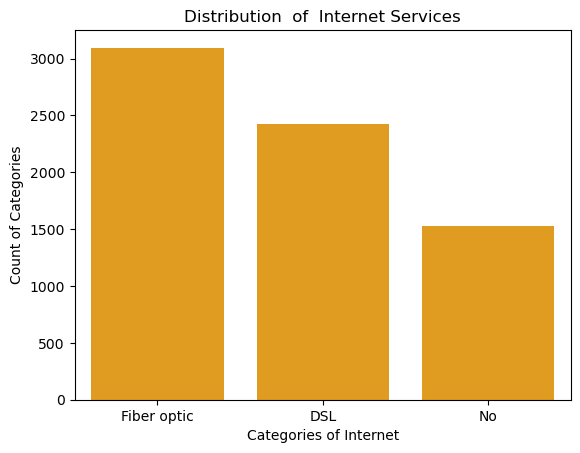

In [44]:
counts=df['InternetService'].value_counts()
    
    

sns.barplot(x=counts.index ,y=counts.values ,color= 'orange')
plt.xlabel('Categories of Internet')
plt.ylabel('Count of Categories')
plt.title('Distribution  of  Internet Services')
plt.show()

In [45]:
# ● Build a histogram for the ‘tenure’ column:
# a. Set the number of bins to be 30
# b. Set the color of the bins to be ‘green’
# c. Assign the title ‘Distribution of tenure’

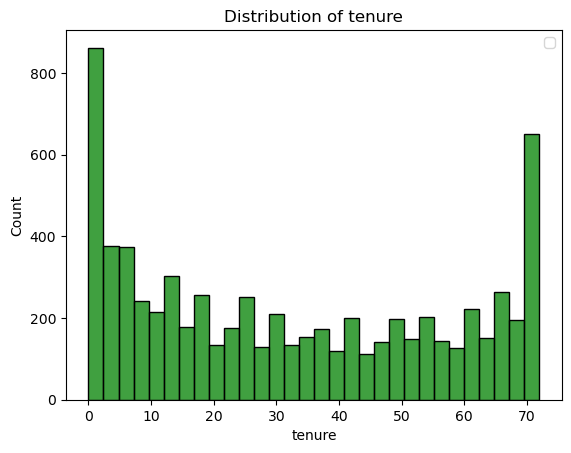

In [46]:
sns.histplot(data=df['tenure'] , color='green' , bins=30,)
plt.title('Distribution of tenure')
plt.legend()
plt.show()

In [47]:
# ● Build a scatter-plot between ‘MonthlyCharges’ and ‘tenure’. Map
# ‘MonthlyCharges’ to the y-axis and ‘tenure’ to the ‘x-axis’:
# a. Assign the points a color of ‘brown’
# b. Set the x-axis label to ‘Tenure of customer’
# c. Set the y-axis label to ‘Monthly Charges of customer’
# d. Set the title to ‘Tenure vs Monthly Charges’
# e. Build a box-plot between ‘tenure’ & ‘Contract’. Map ‘tenure’ on the
# y-axis &
# f. ‘Contract’ on the x-axis.

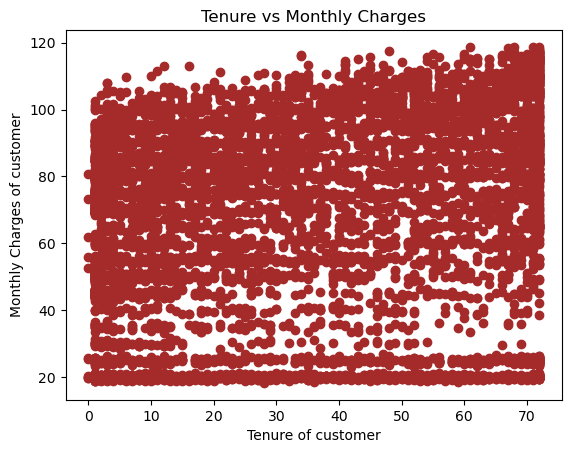

In [48]:
plt.scatter(y=df['MonthlyCharges'],x=df['tenure'] , color='brown' )
plt.xlabel('Tenure of customer')
plt.ylabel('Monthly Charges of customer')
plt.title('Tenure vs Monthly Charges')
plt.show()


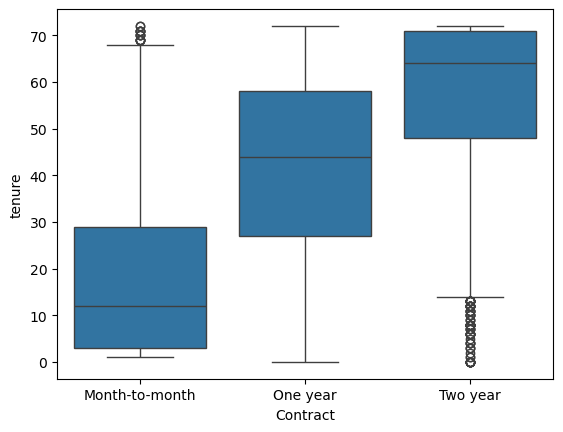

In [49]:
# boxplot between tenure and contract
sns.boxplot(x=df['Contract'] , y=df['tenure'])
plt.show()

In [50]:
## 3. 📈 Linear Regression — Monthly Charges Prediction

Building a simple linear regression model to understand the relationship between **tenure** (independent) and **MonthlyCharges** (dependent). While not a core churn model, this establishes baseline understanding of billing patterns over time.

In [51]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1936.30,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,107.70,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1903.50,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,141.40,1


In [52]:
df['tenure'].value_counts()

tenure
1     613
72    362
2     238
3     200
4     176
     ... 
28     57
39     56
44     51
36     50
0      11
Name: count, Length: 73, dtype: int64

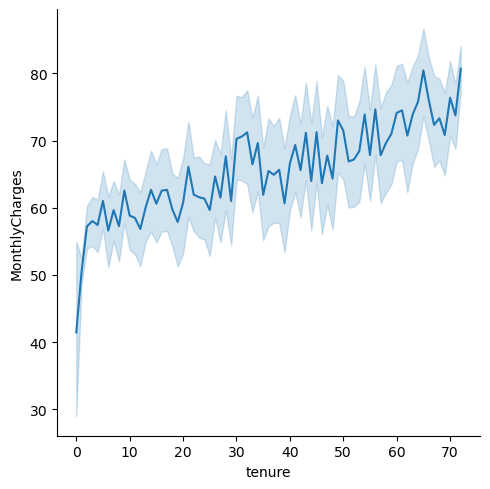

In [53]:
sns.relplot ( data=df,x='tenure', y='MonthlyCharges' ,  kind='line' )
plt.show()

In [54]:
# model building 
x=df[['tenure']]#independent variable
y=df[['MonthlyCharges']] #dependent variable

In [55]:
from sklearn.preprocessing import StandardScaler

In [56]:
ss=StandardScaler()

In [57]:

from sklearn.model_selection import train_test_split

In [58]:
x_train , x_test , y_train , y_test = train_test_split( x,y, test_size=.30 , random_state=42 )

In [59]:
# model initailization

In [60]:
from sklearn.linear_model import LinearRegression

In [61]:
lr=LinearRegression() 

In [62]:
# train the model 

In [63]:
lr.fit(x_train , y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [64]:
lr.coef_

array([[0.30821548]])

In [65]:
lr.intercept_

array([54.79837463])

In [66]:
y_pred=lr.predict(x_test)

In [67]:
x_test

,tenure
185,1
2715,41
3825,52
1807,1
132,67
...,...
5522,1
6377,1
5500,60
2392,20


In [68]:
y_test

,MonthlyCharges
185,24.80
2715,25.25
3825,19.35
1807,76.35
132,50.55
...,...
5522,70.15
6377,44.65
5500,60.50
2392,90.70


In [69]:
from sklearn.metrics import mean_squared_error , mean_absolute_error,r2_score

In [70]:
# model evaluation
mean_absolute_error(y_test , y_pred )

25.225560821286088

In [71]:
a=mean_squared_error(y_test , y_pred)
a


845.6091871095869

In [72]:
r2_score(y_test , y_pred)

0.05856035027031614

In [73]:
#root mean squared error
np.sqrt(a)

np.float64(29.07936015646814)

In [74]:
error= y_test - y_pred
error


,MonthlyCharges
185,-30.306590
2715,-42.185209
3825,-51.475579
1807,21.243410
132,-24.898812
...,...
5522,15.043410
6377,-10.456590
5500,-12.791303
2392,29.737316


In [75]:
## 4. 🔢 Logistic Regression — Churn Classification

Two logistic regression experiments:
- **Simple model:** Single feature (`MonthlyCharges`) → 65/35 split
- **Multiple model:** Two features (`tenure` + `MonthlyCharges`) → 80/20 split

Logistic regression provides a solid interpretable baseline before moving to ensemble and deep learning models.

In [76]:
X=df[['MonthlyCharges']]
Y=df['Churn']

In [77]:
Y.value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

In [78]:
from sklearn.model_selection import train_test_split

In [79]:
X_train , X_test , Y_train , Y_test = train_test_split( X , Y , test_size=0.35 , random_state=42)

In [80]:
X_train[:10]

,MonthlyCharges
3143,72.80
192,19.75
6251,19.25
1126,74.65
2689,116.75
2707,98.70
6890,61.10
304,81.85
2957,80.30
1292,84.50


In [81]:
Y_train[:10]

3143    0
192     0
6251    0
1126    1
2689    0
2707    1
6890    0
304     0
2957    0
1292    0
Name: Churn, dtype: int64

In [82]:
X_test

,MonthlyCharges
185,24.80
2715,25.25
3825,19.35
1807,76.35
132,50.55
...,...
5940,85.85
1788,19.60
5101,106.65
6549,56.25


In [83]:
Y_test

185     1
2715    0
3825    0
1807    1
132     0
       ..
5940    0
1788    0
5101    0
6549    1
528     0
Name: Churn, Length: 2466, dtype: int64

In [84]:
# from sklearn.preprocessing import LabelEncoder
# le=LabelEncoder()
# for col in df.columns:
#     if df[col].dtype =='object':
#         df[col]= le.fit_transform(df[col])
# this is the code for performing labelEncoder but as of now  we do not have multiple feature so it is not needed .

In [85]:
from sklearn.linear_model import LogisticRegression

In [86]:
LR=LogisticRegression()

In [87]:
LR.fit(X_train , Y_train )

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [88]:
Y_pred = LR.predict(X_test)

In [89]:
from sklearn.metrics import *

In [90]:
cf=confusion_matrix(Y_test , Y_pred )
cf

array([[1797,    0],
       [ 669,    0]])

In [91]:
accuracy_score(Y_test,Y_pred)*100

72.87104622871047

# Building another model where two independent variables are present 

In [92]:
x=df[['tenure', 'MonthlyCharges']]
y=df['Churn']

In [93]:
x.head()

,tenure,MonthlyCharges
0,1,29.85
1,34,56.95
2,2,53.85
3,45,42.30
4,2,70.70


In [94]:
y.head()

0    0
1    0
2    1
3    0
4    1
Name: Churn, dtype: int64

In [95]:
from sklearn.model_selection import train_test_split

In [96]:
x_train , x_test , y_train , y_test = train_test_split( x , y , test_size=.20 , random_state=42 )

In [97]:
x_train[:10]

,tenure,MonthlyCharges
2142,21,64.85
1623,54,97.20
6074,1,23.45
1362,4,70.20
6754,0,61.90
1212,7,69.55
2722,32,18.95
4006,72,19.80
6791,19,39.65
5466,10,19.95


In [98]:
y_train[:10]

2142    0
1623    0
6074    1
1362    1
6754    0
1212    0
2722    0
4006    0
6791    1
5466    0
Name: Churn, dtype: int64

In [99]:
from sklearn.linear_model import LogisticRegression

In [100]:
model=LogisticRegression()

In [101]:
model.fit(x_train , y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [102]:
y_pred = model.predict(x_test )

In [103]:
from sklearn.metrics import*

In [104]:
confusion_matrix(y_test, y_pred )

array([[944,  92],
       [193, 180]])

In [105]:
accuracy_score(y_test , y_pred )*100

79.77288857345636

In [106]:
## 5. 🌳 Decision Tree & Feature Selection

Decision Tree classifier using `tenure` as the sole predictor, followed by **Random Forest + RFE (Recursive Feature Elimination)** to identify the top 5 most predictive features from all 19 available columns.

The top 5 RFE-selected features are then used as input to the deep learning model.

In [107]:
x=df[['tenure']]
y=df['Churn']

In [108]:
from sklearn.model_selection import train_test_split

In [109]:
x_train , x_test , y_train , y_test = train_test_split( x , y , test_size = .20 , random_state = 42 )

In [110]:
x_train.head()

,tenure
2142,21
1623,54
6074,1
1362,4
6754,0


In [111]:
x_test.head()

,tenure
185,1
2715,41
3825,52
1807,1
132,67


In [112]:
y_train.head()

2142    0
1623    0
6074    1
1362    1
6754    0
Name: Churn, dtype: int64

In [113]:
from sklearn.tree import  DecisionTreeClassifier

In [114]:
dt= DecisionTreeClassifier()

In [115]:
dt.fit(x_train ,  y_train )

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [116]:
y_pred=dt.predict(x_test)

In [117]:
from sklearn.metrics import *

In [118]:
confusion_matrix(y_test , y_pred )

array([[951,  85],
       [257, 116]])

In [119]:
print(classification_report(y_test , y_pred ))

              precision    recall  f1-score   support

           0       0.79      0.92      0.85      1036
           1       0.58      0.31      0.40       373

    accuracy                           0.76      1409
   macro avg       0.68      0.61      0.63      1409
weighted avg       0.73      0.76      0.73      1409



In [120]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import *
from sklearn.feature_selection import RFE



numerical_features = ['gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges']

for col in numerical_features:
  if df[col].dtype == 'object':
    df[col] = pd.factorize(df[col])[0]
# specifying numerical columns
numerical_features = [f for f in numerical_features if f in df.columns]
X = df[numerical_features]
y=df['Churn']

#rfe needs a baseline algorithm to work
rf = RandomForestClassifier(n_estimators=150, random_state=42)
rfe = RFE(estimator=rf, n_features_to_select=5)
rfe.fit(X,y)

,estimator,RandomForestC...ndom_state=42)
,n_features_to_select,5
,step,1
,verbose,0
,importance_getter,'auto'
,n_estimators,150
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0


In [121]:
selected_features = [feature for feature, selected in zip(numerical_features, rfe.support_) if selected]
selected_features

['tenure', 'OnlineSecurity', 'Contract', 'MonthlyCharges', 'TotalCharges']

In [122]:
rf.fit(X,y)
importances = pd.DataFrame({"feature":numerical_features,
                            "importance":rf.feature_importances_})
importances = importances.sort_values('importance', ascending=False)
importances

,feature,importance
18,TotalCharges,0.188937
17,MonthlyCharges,0.177272
4,tenure,0.160166
14,Contract,0.080055
16,PaymentMethod,0.056147
8,OnlineSecurity,0.045372
11,TechSupport,0.038637
0,gender,0.028049
15,PaperlessBilling,0.025324
7,InternetService,0.024642


<Axes: xlabel='importance', ylabel='feature'>

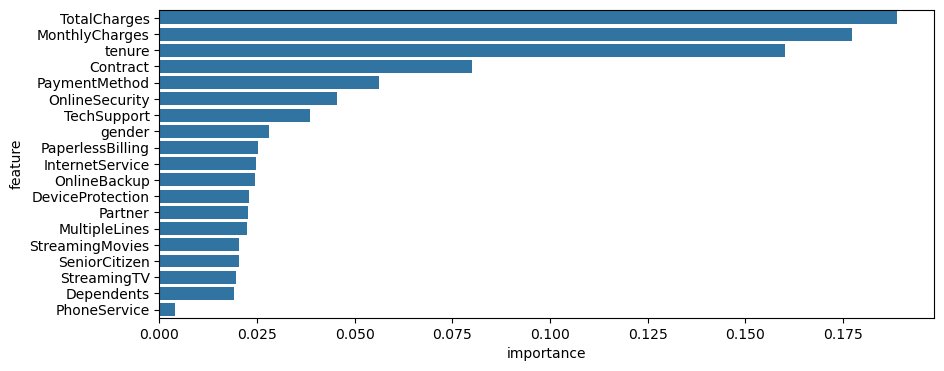

In [123]:
plt.figure(figsize=(10,4))
sns.barplot(x='importance', y ='feature', data=importances)

In [124]:
selected_features

['tenure', 'OnlineSecurity', 'Contract', 'MonthlyCharges', 'TotalCharges']

In [125]:
X = df[selected_features]
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X,y, test_size=0.20, random_state=42
)

In [126]:
X.head(5)

,tenure,OnlineSecurity,Contract,MonthlyCharges,TotalCharges
0,1,0,0,29.85,29.85
1,34,1,1,56.95,1936.30
2,2,1,0,53.85,107.70
3,45,1,1,42.30,1903.50
4,2,0,0,70.70,141.40


In [127]:
X.describe()

,tenure,OnlineSecurity,Contract,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,32.371149,0.720006,0.690473,64.761692,2279.581350
std,24.559481,0.796885,0.833755,30.090047,2264.729447
min,0.000000,0.000000,0.000000,18.250000,0.000000
25%,9.000000,0.000000,0.000000,35.500000,394.000000
50%,29.000000,1.000000,0.000000,70.350000,1393.600000
75%,55.000000,1.000000,1.000000,89.850000,3786.100000
max,72.000000,2.000000,2.000000,118.750000,8550.000000


In [128]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [129]:
#scaler i have used i can save it -> use it later
with open('scaler.pkl',"wb") as f:
  pickle.dump(scaler, f)

## 6. 🧠 Deep Neural Network with Keras Tuner

Building a deep learning classifier on the **5 RFE-selected features** with two phases:

**Phase 1 — Baseline DNN:**  
A fixed architecture (64→32→16→8→1) trained for 50 epochs to establish a performance benchmark.

**Phase 2 — Hyperparameter Tuning (Keras Tuner):**  
`RandomSearch` tuner explores combinations of layer sizes (`[32, 64, 128]`) and optional second layer presence. Best hyperparameters are selected based on `val_accuracy` and used to retrain the final model.

**Model Persistence:**  
The trained model (`best_churn_model.h5`), scaler (`scaler.pkl`), and selected features (`selected_features.pkl`) are saved for deployment.


In [130]:
def create_model(hp=None):
  if hp:
    model = models.Sequential()
    model.add(layers.Dense(
        units=hp.Choice('units_1',values=[32,64,128]),
        activation = 'relu',
        input_shape=(5,)
    ))

    #random activation
    if hp.Boolean('second_layer'):
      model.add(layers.Dense(
          units=hp.Choice("units_2",values=[16,32]),
          activation='relu'
      ))

    model.add(layers.Dense(1, activation='sigmoid'))
    model.compile(
        optimizer='adam',loss='binary_crossentropy',metrics=['accuracy']
    )
  else:
    model=models.Sequential([
        layers.Dense(64, activation='relu',input_shape=(5,)),
        layers.Dense(32,activation='relu'),
        layers.Dense(16,activation='relu'),
        layers.Dense(8,activation='relu'),
        layers.Dense(1,activation='sigmoid'),
    ])
    model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

  return model

In [131]:
initial_model = create_model()
initial_model.summary() #default = assumption

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │             384 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 8)                   │             136 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 1)                   │               9 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,137 (12.25 KB)

 Trainable params: 3,137 (12.25 KB)

 Non-trainable params: 0 (0.00 B)

In [132]:
initial_model = create_model()

In [133]:
print(X_train_scaled.dtype)
print(y_train.dtype)

float64
int64


In [134]:
history = initial_model.fit(
    X_train_scaled, y_train,
    epochs = 50,
    batch_size=32,
    validation_split=0.20
)

Epoch 1/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.7548 - loss: 0.5227 - val_accuracy: 0.7826 - val_loss: 0.4261
Epoch 2/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7843 - loss: 0.4456 - val_accuracy: 0.7977 - val_loss: 0.4219
Epoch 3/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7890 - loss: 0.4392 - val_accuracy: 0.7888 - val_loss: 0.4078
Epoch 4/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7886 - loss: 0.4357 - val_accuracy: 0.7977 - val_loss: 0.4050
Epoch 5/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7943 - loss: 0.4338 - val_accuracy: 0.7924 - val_loss: 0.4044
Epoch 6/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7923 - loss: 0.4316 - val_accuracy: 0.7959 - val_loss: 0.4077
Epoch 7/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7948 - loss: 0.4301 - val_accuracy: 0.7968 - val_loss: 0.4068
Epoch 8/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7972 - loss: 0.4306 - val_accuracy: 0.

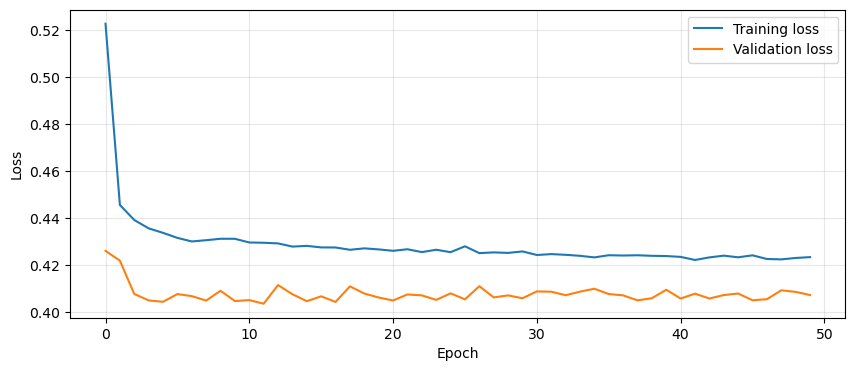

In [135]:
plt.figure(figsize=(10,4))
plt.plot(history.history['loss'], label = "Training loss")
plt.plot(history.history['val_loss'], label = "Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)

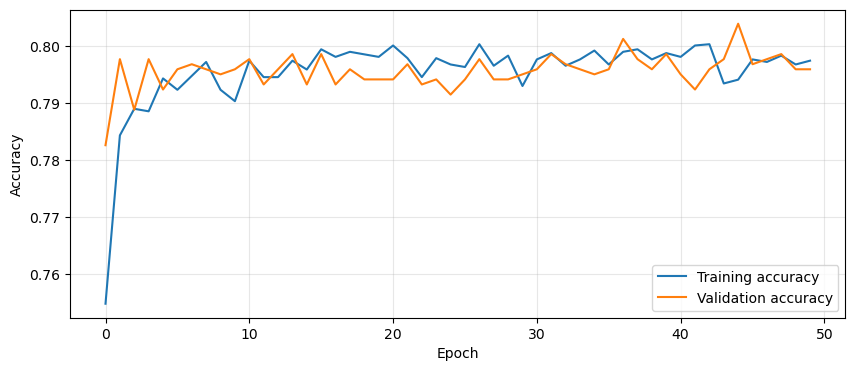

In [136]:
plt.figure(figsize=(10,4))
plt.plot(history.history['accuracy'], label = "Training accuracy")
plt.plot(history.history['val_accuracy'], label = "Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)

In [137]:
!pip install keras-tuner

In [138]:
import keras_tuner as kt
import tensorflow as tf

In [139]:
tuner = kt.RandomSearch(            
    create_model,
    objective = "val_accuracy",
    max_trials=5,
    directory = 'keras_tuning',
    project_name="churn_prediction"
)

stop_early = tf.keras.callbacks.EarlyStopping(monitor='val_loss',patience=3)

Reloading Tuner from keras_tuning\churn_prediction\tuner0.json


In [140]:
tuner.search(X_train_scaled, y_train,
             epochs=20,
             validation_split=0.20,
             callbacks=[stop_early])

In [141]:
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]
for param in best_hps.values:
  print(f"{param} : {best_hps.get(param)}")

units_1 : 64
second_layer : False
units_2 : 32


In [142]:
best_model = tuner.hypermodel.build(best_hps)

#callbacks-> Early stopping, model check
#more epochs -> mode over fit high, pat low, 3,2,4 , dropout inclrese couint
best_history = best_model.fit(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.7535 - loss: 0.5149 - val_accuracy: 0.7844 - val_loss: 0.4409
Epoch 2/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7746 - loss: 0.4588 - val_accuracy: 0.7826 - val_loss: 0.4262
Epoch 3/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7766 - loss: 0.4508 - val_accuracy: 0.7888 - val_loss: 0.4182
Epoch 4/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7821 - loss: 0.4459 - val_accuracy: 0.7879 - val_loss: 0.4128
Epoch 5/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7881 - loss: 0.4424 - val_accuracy: 0.7906 - val_loss: 0.4096
Epoch 6/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7874 - loss: 0.4402 - val_accuracy: 0.7897 - val_loss: 0.4086
Epoch 7/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7877 - loss: 0.4382 - val_accuracy: 0.7924 - val_loss: 0.4061
Epoch 8/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7897 - loss: 0.4373 - val_accuracy: 0

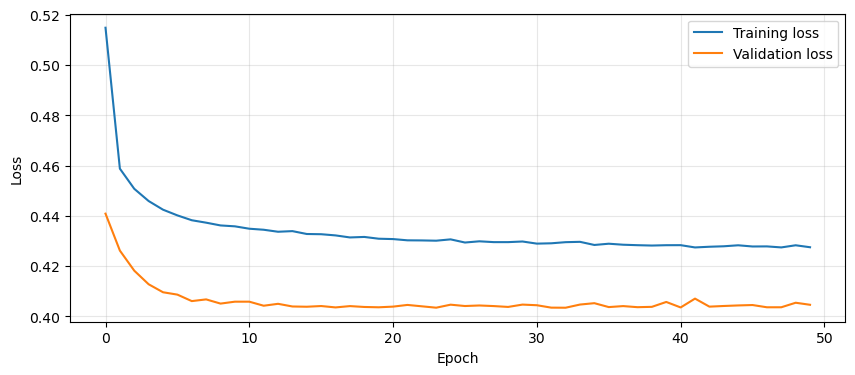

In [143]:
plt.figure(figsize=(10,4))
plt.plot(best_history.history['loss'], label = "Training loss")
plt.plot(best_history.history['val_loss'], label = "Validation loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)

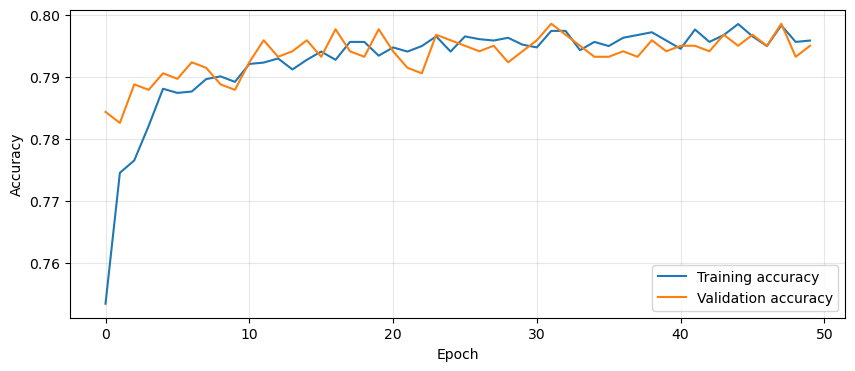

In [144]:
plt.figure(figsize=(10,4))
plt.plot(best_history.history['accuracy'], label = "Training accuracy")
plt.plot(best_history.history['val_accuracy'], label = "Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(alpha=0.3)

In [145]:
best_model.save("best_churn_model.h5")

---

## ✅ Project Summary

| Model | Features Used | Split | Metric |
|-------|--------------|-------|--------|
| Linear Regression | tenure → MonthlyCharges | 70/30 | RMSE, MAE, R² |
| Logistic Regression (Simple) | MonthlyCharges | 65/35 | Accuracy, Confusion Matrix |
| Logistic Regression (Multi) | tenure + MonthlyCharges | 80/20 | Accuracy, Confusion Matrix |
| Decision Tree | tenure | 80/20 | Accuracy, Classification Report |
| Random Forest + RFE | All 19 features → Top 5 | — | Feature Importance |
| Deep Neural Network (Baseline) | Top 5 RFE features | 80/20 | Loss, Accuracy curves |
| **DNN + Keras Tuner (Best Model)** | **Top 5 RFE features** | **80/20** | **val_accuracy (optimised)** |

**Best performing model:** Tuned Deep Neural Network selected via Keras RandomSearch  
**Saved artifacts:** `best_churn_model.h5` · `scaler.pkl` · `selected_features.pkl`
